# Modelo Lineal

In [2]:
%cd ..

c:\Users\juanw\Desktop\garbage-classification


In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from src.carga import cargar_datos
import cv2
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report,accuracy_score
import os

## Carga de los datos

In [5]:
root = 'data/Garbage-classification/Garbage-classification/'
df = cargar_datos(root)
df.head()

,x,y
443,data/Garbage-classification/Garbage-classifica...,glass
350,data/Garbage-classification/Garbage-classifica...,cardboard
2040,data/Garbage-classification/Garbage-classifica...,plastic
739,data/Garbage-classification/Garbage-classifica...,glass
288,data/Garbage-classification/Garbage-classifica...,cardboard


## Division de los datos

In [6]:
from sklearn.model_selection import train_test_split

# 80% train, 20% (test + validación)
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['y']
 )

# Del 20% (test + validacion): 10% validación y 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['y']
 )

print(f"Train: {len(train_df)} ({len(train_df)/len(df):.1%})")
print(f"Validación: {len(val_df)} ({len(val_df)/len(df):.1%})")
print(f"Test: {len(test_df)} ({len(test_df)/len(df):.1%})")

Train: 2021 (80.0%)
Validación: 253 (10.0%)
Test: 253 (10.0%)


## Modificacion de las imagenes y carga en memoria.

Al aplicar modelos lineales los cuales no tienen como argumento el batch_size tenemos que hacer la carga de todas las imagenes en memoria y transformarlas a un vector unico por imagen para poder darselas al modelo.

In [7]:
def load_images(df, size):
    images = []
    labels = []
    
    for _, row in df.iterrows():
        ruta = row['x']
        label = row['y']
        
        img = cv2.imread(ruta)                  
        img = cv2.resize(img, (size, size))    
        img = img.astype('float32') / 255.0    
        
        images.append(img)
        labels.append(label)
    
    X = np.array(images)
    y = np.array(labels)
    
    return X, y

In [8]:
x_train, y_train = load_images(train_df, size=128)
x_val, y_val = load_images(val_df, size=128)
x_test, y_test = load_images(test_df, size=128)

In [9]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((2021, 128, 128, 3),
 (2021,),
 (253, 128, 128, 3),
 (253,),
 (253, 128, 128, 3),
 (253,))

Aplanamos las imagenes para poder pasarle al modelo lineal cada imagen como un vector unico

In [10]:
X_train = x_train.reshape(x_train.shape[0], -1)
X_val   = x_val.reshape(x_val.shape[0], -1)
X_test  = x_test.reshape(x_test.shape[0], -1)

Encoding para los lebels

In [11]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val  = le.transform(y_val)
y_test  = le.transform(y_test)

In [12]:
le.classes_

array(['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash'],
      dtype='<U9')

## Aplicamos el modelo de clasificación

In [13]:
model = LogisticRegression(max_iter=2000, random_state=42)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [14]:
# Predicciones
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)



In [15]:
print(classification_report(y_train, y_train_pred, target_names=le.classes_))

              precision    recall  f1-score   support

   cardboard       1.00      1.00      1.00       322
       glass       1.00      1.00      1.00       401
       metal       1.00      1.00      1.00       328
       paper       1.00      1.00      1.00       475
     plastic       0.99      1.00      1.00       385
       trash       1.00      1.00      1.00       110

    accuracy                           1.00      2021
   macro avg       1.00      1.00      1.00      2021
weighted avg       1.00      1.00      1.00      2021



In [16]:
print(classification_report(y_val, y_val_pred, target_names=le.classes_))

              precision    recall  f1-score   support

   cardboard       0.45      0.55      0.49        40
       glass       0.34      0.44      0.39        50
       metal       0.35      0.20      0.25        41
       paper       0.56      0.48      0.52        60
     plastic       0.52      0.54      0.53        48
       trash       0.33      0.36      0.34        14

    accuracy                           0.44       253
   macro avg       0.43      0.43      0.42       253
weighted avg       0.44      0.44      0.44       253



In [17]:


print(classification_report(y_test, y_test_pred, target_names=le.classes_))

              precision    recall  f1-score   support

   cardboard       0.50      0.46      0.48        41
       glass       0.31      0.38      0.34        50
       metal       0.30      0.24      0.27        41
       paper       0.51      0.51      0.51        59
     plastic       0.33      0.37      0.35        49
       trash       0.14      0.08      0.10        13

    accuracy                           0.38       253
   macro avg       0.35      0.34      0.34       253
weighted avg       0.38      0.38      0.38       253



In [18]:
def plot_confusion(y_true, y_pred, class_names, title='Matriz de confusion'):
    # Redondear predicciones a etiquetas enteras
    y_pred_labels = np.rint(y_pred).astype(int)
    y_pred_labels = np.clip(y_pred_labels, 0, len(class_names) - 1)

    labels = list(range(len(class_names)))
    cm = confusion_matrix(y_true, y_pred_labels, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.tight_layout()
    plt.show()



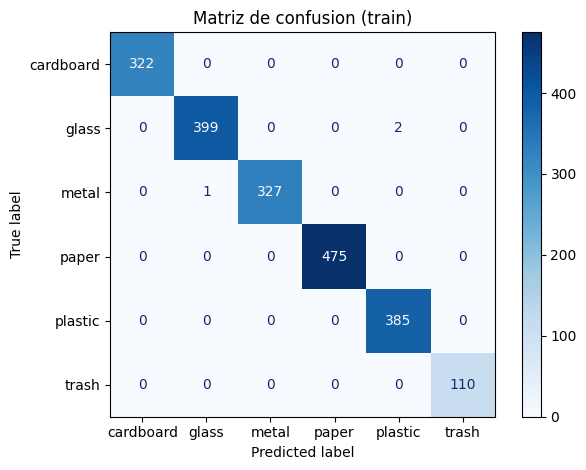

In [19]:
plot_confusion(y_train, y_train_pred, le.classes_, title='Matriz de confusion (train)')

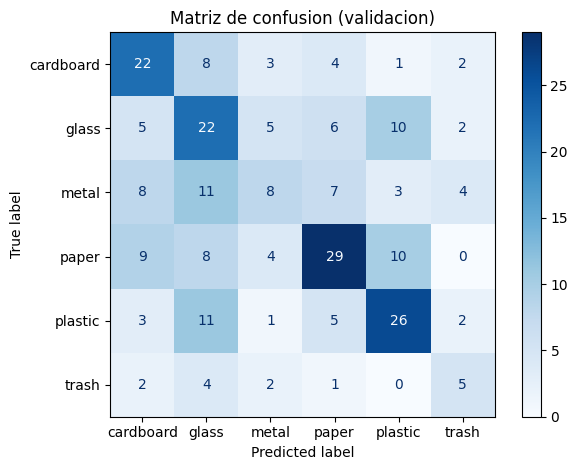

In [20]:
plot_confusion(y_val, y_val_pred, le.classes_, title='Matriz de confusion (validacion)')

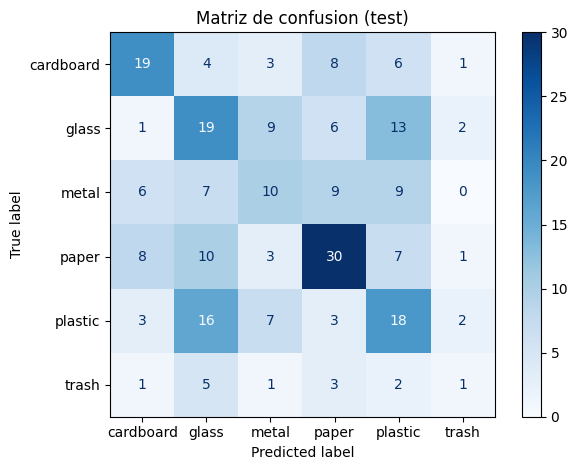

In [21]:
plot_confusion(y_test, y_test_pred, le.classes_, title='Matriz de confusion (test)')

## Modelo de Machine Learning

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [23]:
model2 = RandomForestClassifier(random_state=42, n_jobs=1)

In [24]:
#Buscamos mejores parametros 
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


grid_search = GridSearchCV(
    estimator=model2,
    param_grid=param_grid,
    cv=3,  # 3-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

In [25]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 15, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

In [26]:
# Usar el mejor modelo encontrado
model2 = grid_search.best_estimator_

In [27]:
y_train_pred2 = model2.predict(X_train)
y_val_pred2 = model2.predict(X_val)
y_test_pred2 = model2.predict(X_test)

In [28]:

acc_train_rf = accuracy_score(y_train, y_train_pred2)
acc_val_rf = accuracy_score(y_val, y_val_pred2)
acc_test_rf = accuracy_score(y_test, y_test_pred2)

print(f"Random Forest - Accuracy Train: {acc_train_rf:.4f}")
print(f"Random Forest - Accuracy Val: {acc_val_rf:.4f}")
print(f"Random Forest - Accuracy Test: {acc_test_rf:.4f}")

Random Forest - Accuracy Train: 0.9975
Random Forest - Accuracy Val: 0.6917
Random Forest - Accuracy Test: 0.6640


In [29]:
print("Classification Report - Train:")
print(classification_report(y_train, y_train_pred2, target_names=le.classes_))

Classification Report - Train:
              precision    recall  f1-score   support

   cardboard       1.00      0.99      1.00       322
       glass       1.00      1.00      1.00       401
       metal       1.00      1.00      1.00       328
       paper       1.00      1.00      1.00       475
     plastic       0.99      1.00      0.99       385
       trash       1.00      1.00      1.00       110

    accuracy                           1.00      2021
   macro avg       1.00      1.00      1.00      2021
weighted avg       1.00      1.00      1.00      2021



In [30]:
print("Classification Report - Validation:")
print(classification_report(y_val, y_val_pred2, target_names=le.classes_))

Classification Report - Validation:
              precision    recall  f1-score   support

   cardboard       0.77      0.90      0.83        40
       glass       0.58      0.72      0.64        50
       metal       0.71      0.37      0.48        41
       paper       0.73      0.90      0.81        60
     plastic       0.66      0.60      0.63        48
       trash       1.00      0.36      0.53        14

    accuracy                           0.69       253
   macro avg       0.74      0.64      0.65       253
weighted avg       0.71      0.69      0.68       253



In [31]:
print("Classification Report - Test:")
print(classification_report(y_test, y_test_pred2, target_names=le.classes_))

Classification Report - Test:
              precision    recall  f1-score   support

   cardboard       0.67      0.71      0.69        41
       glass       0.51      0.66      0.57        50
       metal       0.63      0.54      0.58        41
       paper       0.78      0.86      0.82        59
     plastic       0.71      0.59      0.64        49
       trash       1.00      0.31      0.47        13

    accuracy                           0.66       253
   macro avg       0.72      0.61      0.63       253
weighted avg       0.68      0.66      0.66       253



In [32]:
n_params_rf = sum(tree.tree_.node_count for tree in model2.estimators_)
print(f"\nNúmero de parámetros (nodos) del Random Forest: {n_params_rf}")


Número de parámetros (nodos) del Random Forest: 65300


## Aplicacion modelo Deep Learning mas sencillo(CNN)

In [33]:
from src.modelo_simple import estructura_modelo,compilar
from src.curvas import graf_pedida,graf_acc

In [34]:
modelo3,resumen=estructura_modelo(input_shape=(128, 128, 3), num_classes=len(le.classes_))
print(resumen)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 6)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210 (840.00 B)

 Trainable params: 210 (840.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [35]:
modelo3=compilar(modelo3,learning_rate=0.001)

In [36]:
hist = modelo3.fit(x_train,y_train,validation_data=(x_val, y_val),batch_size=128,epochs=200)

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 1.8744 - sparse_categorical_accuracy: 0.0544 - val_loss: 1.8177 - val_sparse_categorical_accuracy: 0.0553
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 1.7990 - sparse_categorical_accuracy: 0.1460 - val_loss: 1.7809 - val_sparse_categorical_accuracy: 0.1976
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 1.7642 - sparse_categorical_accuracy: 0.2128 - val_loss: 1.7503 - val_sparse_categorical_accuracy: 0.2372
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 1.7424 - sparse_categorical_accuracy: 0.2350 - val_loss: 1.7355 - val_sparse_categorical_accuracy: 0.2372
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 1.7299 - sparse_categorical_accuracy: 0.2350 - val_loss: 1.7261 - val_sparse_categorical_accuracy: 0.2372
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 1.7225 - sparse_categorical_accuracy: 0.2350 - val_loss: 1.7195 - val_sparse_categorical_accuracy: 0.2372
Epoc

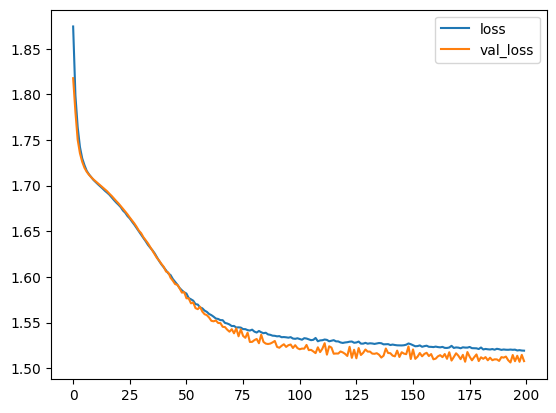

None


In [37]:
grafico = graf_pedida(hist)
print(grafico)

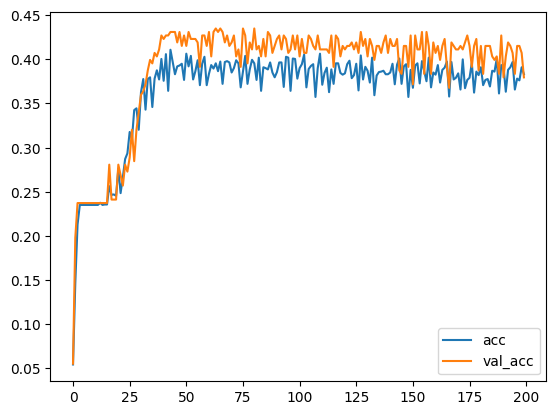

None


In [38]:
grafico2 = graf_acc(hist)
print(grafico2)

### Evaluamos el modelo 

In [39]:
score1 = modelo3.evaluate(x_train, y_train, steps=100)
print(score1)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5184 - sparse_categorical_accuracy: 0.3681
[1.518371820449829, 0.36813458800315857]


In [40]:
score2 = modelo3.evaluate(x_val, y_val, steps=100)
print(score2)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5077 - sparse_categorical_accuracy: 0.3794   
[1.5077189207077026, 0.3794466257095337]


In [41]:
score3 = modelo3.evaluate(x_test, y_test, steps=100)
print(score3)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5626 - sparse_categorical_accuracy: 0.3755
[1.5626448392868042, 0.3754940629005432]


### Matrices de confusion

In [42]:
y_train_pred3 = modelo3.predict(x_train)
y_train_pred3 = y_train_pred3.argmax(axis=1)


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [43]:
y_val_pred3 = modelo3.predict(x_val)
y_val_pred3 = y_val_pred3.argmax(axis=1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [44]:
y_test_pred3 = modelo3.predict(x_test)
y_test_pred3 = y_test_pred3.argmax(axis=1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


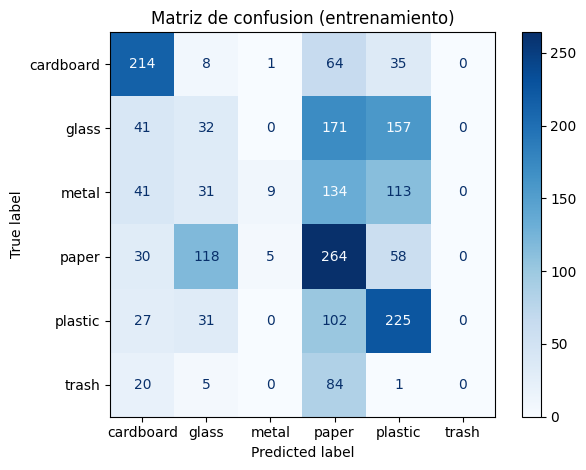

In [45]:
plot_confusion(y_train, y_train_pred3, le.classes_, title='Matriz de confusion (entrenamiento)')

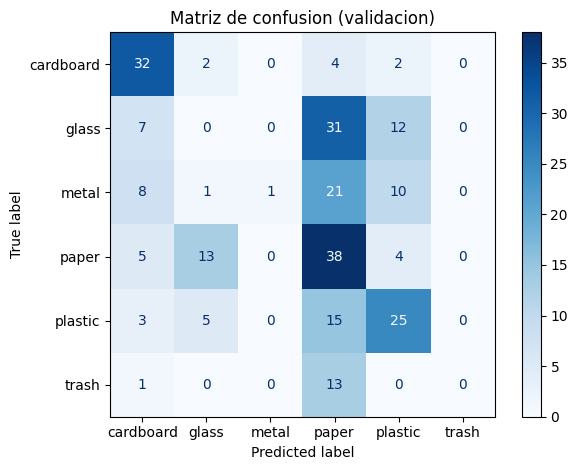

In [46]:
plot_confusion(y_val, y_val_pred3, le.classes_, title='Matriz de confusion (validacion)')

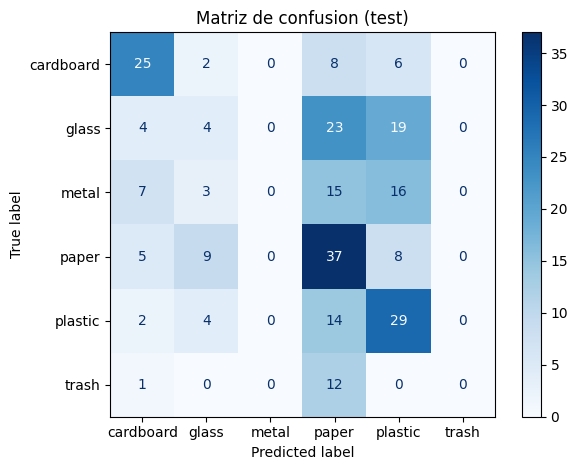

In [47]:
plot_confusion(y_test, y_test_pred3, le.classes_, title='Matriz de confusion (test)')

### Mas metricas

In [48]:
print("Classification Report - Train:")
print(classification_report(y_train, y_train_pred3, target_names=le.classes_))

Classification Report - Train:
              precision    recall  f1-score   support

   cardboard       0.57      0.66      0.62       322
       glass       0.14      0.08      0.10       401
       metal       0.60      0.03      0.05       328
       paper       0.32      0.56      0.41       475
     plastic       0.38      0.58      0.46       385
       trash       0.00      0.00      0.00       110

    accuracy                           0.37      2021
   macro avg       0.34      0.32      0.27      2021
weighted avg       0.37      0.37      0.31      2021



In [49]:
print("Classification Report - validacion:")
print(classification_report(y_val, y_val_pred3, target_names=le.classes_))

Classification Report - validacion:
              precision    recall  f1-score   support

   cardboard       0.57      0.80      0.67        40
       glass       0.00      0.00      0.00        50
       metal       1.00      0.02      0.05        41
       paper       0.31      0.63      0.42        60
     plastic       0.47      0.52      0.50        48
       trash       0.00      0.00      0.00        14

    accuracy                           0.38       253
   macro avg       0.39      0.33      0.27       253
weighted avg       0.42      0.38      0.31       253



In [50]:
print("Classification Report - test:")
print(classification_report(y_test, y_test_pred3, target_names=le.classes_))

Classification Report - test:
              precision    recall  f1-score   support

   cardboard       0.57      0.61      0.59        41
       glass       0.18      0.08      0.11        50
       metal       0.00      0.00      0.00        41
       paper       0.34      0.63      0.44        59
     plastic       0.37      0.59      0.46        49
       trash       0.00      0.00      0.00        13

    accuracy                           0.38       253
   macro avg       0.24      0.32      0.27       253
weighted avg       0.28      0.38      0.31       253

